## **Ridge Regression Word Difficulty Model**

### **Purpose**

The purpose of this model is to estimate the Age of Acquisition (AoA) of a word entered by the user. Since the user input is expected to be a single word, the model was designed to use only features that can be automatically extracted from that word.

The model does not require additional user-provided information such as sentence context, reading history, or child-specific assessment data. Instead, it uses word-level linguistic features such as word length, estimated syllable count, word frequency, vowel ratio, and maximum consonant run. These features are used to train a Ridge Regression model that predicts a continuous AoA score.

The predicted AoA is not presented as an exact developmental judgement. Instead, it is compared with the selected target age and converted into broad, cautious categories such as likely familiar, around target age, or likely unfamiliar. This allows the system to provide a non-diagnostic word-level difficulty indicator.

### **Structure**
This notebook is organized into the following sections

1. Dataset loading and visualization  
2. Feature extraction and label creation  
3. Train / validation / test split  
4. Ridge Regression model implementation  
5. Model training and validation monitoring  
6. Final test result evaluation using regression metrics  
7. Example word prediction and age-level support category output

In [1]:
!pip install wordfreq -q

In [2]:
import re
import json
import numpy as np
import pandas as pd
import wordfreq
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

print('Total rows:', len(df))
df.head()

Saving AoA_refined_v3.xlsx to AoA_refined_v3 (7).xlsx
Total rows: 5889


,Word,Alternative.spelling,Freq_pm,Dom_PoS_SUBTLEX,Nletters,Nphon,Nsyll,Lemma_highest_PoS,AoA_Kup,Perc_known,AoA_Kup_lem,Perc_known_lem,AoA_Bird_lem,AoA_Bristol_lem,AoA_Cort_lem,AoA_Schock,Perc_known_final,AoA_final,Age_Group,AoA_source
0,a,a,20415.274510,Article,1,1,1,a,2.893384,1.0,2.893384,1.0,3.156247,NaN,NaN,NaN,1.0,2.893384,below_6,AoA_Kup
1,abandon,abandon,8.098039,Verb,7,7,3,abandon,8.320000,1.0,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup
2,abandoned,abandoned,13.294118,Verb,9,8,3,abandon,NaN,NaN,8.320000,1.0,NaN,NaN,NaN,NaN,1.0,8.320000,age_8_plus,AoA_Kup_lem
3,abducted,abducted,5.000000,Verb,8,8,3,abduct,NaN,NaN,11.260000,1.0,NaN,NaN,NaN,9.48848,1.0,11.260000,age_8_plus,AoA_Kup_lem
4,abilities,abilities,6.117647,Noun,9,8,4,ability,NaN,NaN,8.840000,1.0,NaN,8.97764,NaN,NaN,1.0,8.840000,age_8_plus,AoA_Kup_lem


In [3]:
PARAMETERS = {
    'seed': 42,
    'word_col': 'Word',
    'target_col': 'AoA_Kup',
    'perc_known_col': 'Perc_known',
    'target_age': 7.0,
    'perc_known_min': 0.3,
    'test_size': 0.2,
    'val_size': 0.2,
    'alpha': 0.001,
    'lr': 0.001,
    'epochs': 3000,
    'log_interval': 100,
    'min_pred_aoa': 1.0,
    'max_pred_aoa': 20.0,
}

# Word-level features extracted from a single input word
FEATURES = [
    'n_letters',          # Number of letters in the cleaned word
    'n_syll_est',         # Estimated number of syllables using a rule-based vowel group method
    'zipf_score',         # Word frequency score from the wordfreq library
    'vowel_ratio',        # Ratio of vowels to total letters
    'max_consonant_run',  # Maximum number of consecutive consonants
]

In [4]:
# Clean a word by keeping only lowercase English alphabet characters
def clean_word(word):
    return re.sub(r'[^a-z]', '', str(word).lower().strip())

# Estimate syllable count
def estimate_syllables(word):
    w = clean_word(word)

    if not w:
        return 1

    vowels = 'aeiouy'
    count = 0
    prev_is_vowel = False

    # Count a syllable when a new vowel group starts
    for ch in w:
        is_vowel = ch in vowels
        if is_vowel and not prev_is_vowel:
            count += 1
        prev_is_vowel = is_vowel

    # Adjust for silent trailing "e"
    if w.endswith('e') and count > 1:
        count -= 1

    return max(count, 1)

# Extract word-level linguistic features from a single input word
def build_features(word):
    cw = clean_word(word)

    n_letters = len(cw)
    n_syll_est = estimate_syllables(cw)
    zipf_score = wordfreq.zipf_frequency(cw, 'en')

    vowels = 'aeiouy'
    n_vowels = sum(1 for ch in cw if ch in vowels)
    vowel_ratio = n_vowels / n_letters if n_letters > 0 else 0.0

    max_consonant_run = 0
    current_run = 0

    # Find the longest sequence of consecutive consonants
    for ch in cw:
        if ch not in vowels:
            current_run += 1
            max_consonant_run = max(max_consonant_run, current_run)
        else:
            current_run = 0

    return {
        'n_letters': float(n_letters),
        'n_syll_est': float(n_syll_est),
        'zipf_score': float(zipf_score),
        'vowel_ratio': float(vowel_ratio),
        'max_consonant_run': float(max_consonant_run),
    }

In [5]:
# Normalize simple plural forms to a base-like form
def normalize_word_form(word):
    w = clean_word(word)

    if not w:
        return w

    # Convert -ies to -y, for example babies -> baby
    if len(w) > 4 and w.endswith('ies'):
        return w[:-3] + 'y'

    # Remove -es for common plural endings, for example boxes -> box
    if len(w) > 4 and w.endswith(('ses', 'xes', 'zes', 'ches', 'shes')):
        return w[:-2]

    # Remove plural -s only when it is less likely to damage common short words
    if (
        len(w) > 4
        and w.endswith('s')
        and not w.endswith(('ss', 'sis', 'ous', 'us', 'is'))
    ):
        return w[:-1]

    return w

In [6]:
# Convert predicted AoA into a broad user-facing category
def aoa_category(pred_aoa, target_age):
    diff = pred_aoa - target_age

    if diff <= -2.0:
        return 'very_likely_familiar'
    if diff <= -0.5:
        return 'likely_familiar'
    if diff < 0.5:
        return 'around_target_age'
    if diff < 2.0:
        return 'likely_unfamiliar'
    return 'very_likely_unfamiliar'

# Convert predicted AoA into a cautious parent-facing message
def aoa_message(pred_aoa, target_age):
    diff = pred_aoa - target_age
    age = int(target_age)

    if diff <= -2.0:
        return f'Most children aged {age} would likely know this word'
    if diff <= -0.5:
        return f'Children aged {age} would likely know this word'
    if diff < 0.5:
        return f'This word may be around the expected level for children aged {age}'
    if diff < 2.0:
        return f'This word may be unfamiliar to children aged {age}'
    return f'This word is likely unfamiliar to children aged {age}'

Final dataset size: 4253
Target AoA range: 1.58 to 14.72
Target AoA mean: 7.18
Target AoA median: 7.05


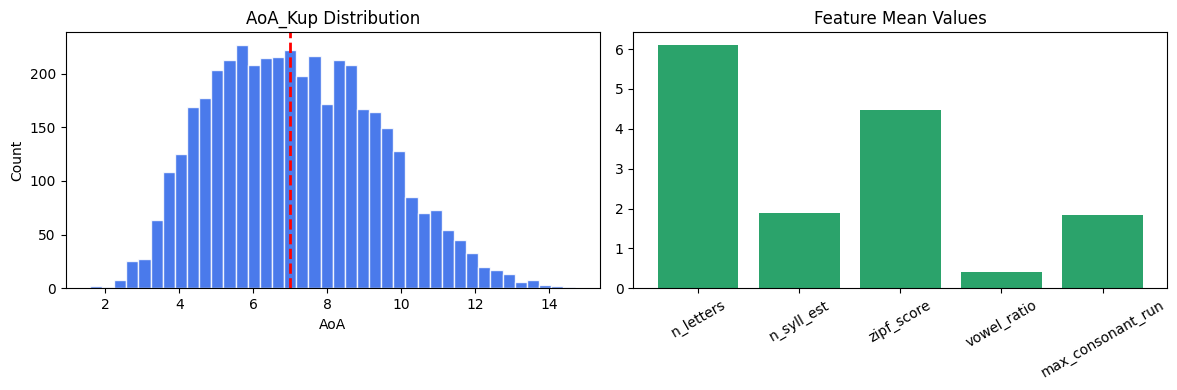

In [7]:
# Remove rows without a valid AoA target value
df = df[df[PARAMETERS['target_col']].notna()].copy()

# Keep only words with enough known-word reliability
df = df[df[PARAMETERS['perc_known_col']] >= PARAMETERS['perc_known_min']].copy()
df[PARAMETERS['word_col']] = df[PARAMETERS['word_col']].astype(str)

# Extract word-level linguistic features for each word
feature_df = df[PARAMETERS['word_col']].apply(build_features).apply(pd.Series)
df = pd.concat([df, feature_df], axis=1)

# Remove rows with missing feature values or missing target values
df = df.dropna(subset=FEATURES + [PARAMETERS['target_col']]).reset_index(drop=True)
df['target_aoa'] = df[PARAMETERS['target_col']].astype(float)
print('Final dataset size:', len(df))
print(f"Target AoA range: {df['target_aoa'].min():.2f} to {df['target_aoa'].max():.2f}")
print(f"Target AoA mean: {df['target_aoa'].mean():.2f}")
print(f"Target AoA median: {df['target_aoa'].median():.2f}")

# Visualize AoA distribution and average feature values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of AoA values
axes[0].hist(
    df[PARAMETERS['target_col']],
    bins=40,
    color='#2A63E8',
    alpha=0.85,
    edgecolor='white'
)

# Mark the selected target age on the AoA distribution
axes[0].axvline(
    PARAMETERS['target_age'],
    color='red',
    linestyle='--',
    linewidth=2
)
axes[0].set_title(f"{PARAMETERS['target_col']} Distribution")
axes[0].set_xlabel('AoA')
axes[0].set_ylabel('Count')

# Plot average values of the extracted features
feature_means = df[FEATURES].mean()
axes[1].bar(feature_means.index, feature_means.values, color='#2BA36B')
axes[1].set_title('Feature Mean Values')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [8]:
# Convert selected feature columns into model input array
X = df[FEATURES].values.astype(float)

# Convert continuous AoA target into regression target array
y = df['target_aoa'].values.astype(float)

# First split: keep the test set separate for final evaluation
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=PARAMETERS['test_size'],
    random_state=PARAMETERS['seed']
)

# Second split: split remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=PARAMETERS['val_size'],
    random_state=PARAMETERS['seed']
)
print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 2721 | Val: 681 | Test: 851


In [9]:
# Standardize features using only the training set statistics
class StandardScaler:
    def fit(self, X):
        X = np.asarray(X, dtype=float)
        # Store mean and standard deviation for each feature
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.scale_[self.scale_ == 0] = 1.0

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Apply standardization using stored training statistics
        return (X - self.mean_) / self.scale_

In [10]:
# Ridge Regression model trained with gradient descent
class RidgeRegression:
    def __init__(self, alpha, lr, epochs):
        self.alpha = alpha
        self.lr = lr
        self.epochs = epochs

    # Compute mean squared error with L2 regularization
    def _loss(self, X, y):
        preds = X @ self.w_ + self.b_
        mse = np.mean((preds - y) ** 2)
        reg = self.alpha * np.sum(self.w_ ** 2)
        return mse + reg

    # Compute mean absolute error
    def _mae(self, X, y):
        preds = self.predict(X)
        return np.mean(np.abs(preds - y))

    # Train the Ridge Regression model and optionally monitor validation performance
    def fit(self, X, y, X_val=None, y_val=None, print_every=500):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if X_val is not None:
            X_val = np.asarray(X_val, dtype=float)
        if y_val is not None:
            y_val = np.asarray(y_val, dtype=float)

        n, p = X.shape

        # Initialize weights and bias
        self.w_ = np.zeros(p, dtype=float)
        self.b_ = float(np.mean(y))

        # Store learning history for visualization and reporting
        self.loss_history_ = []
        self.train_mae_history_ = []
        self.val_loss_history_ = []
        self.val_mae_history_ = []

        for epoch in range(1, self.epochs + 1):
            # Forward prediction
            preds = X @ self.w_ + self.b_
            errors = preds - y

            # Calculate training loss
            loss = self._loss(X, y)
            self.loss_history_.append(loss)

            # Calculate gradients
            grad_w = (2 / n) * (X.T @ errors) + 2 * self.alpha * self.w_
            grad_b = 2 * np.mean(errors)

            # Apply learning rate decay
            lr_t = self.lr / (1 + 0.001 * epoch)
            self.w_ -= lr_t * grad_w
            self.b_ -= lr_t * grad_b

            # Track training MAE
            train_mae = self._mae(X, y)
            self.train_mae_history_.append(train_mae)

            # Track validation loss and MAE if validation data is provided
            if X_val is not None and y_val is not None:
                val_loss = self._loss(X_val, y_val)
                val_mae = self._mae(X_val, y_val)
                self.val_loss_history_.append(val_loss)
                self.val_mae_history_.append(val_mae)

            # Print learning progress
            if epoch == 1 or epoch % print_every == 0 or epoch == self.epochs:
                if X_val is not None and y_val is not None:
                    print(
                        f'Epoch {epoch:>5}/{self.epochs}  '
                        f'train_loss={loss:.4f}  '
                        f'train_mae={train_mae:.4f}  '
                        f'val_loss={val_loss:.4f}  '
                        f'val_mae={val_mae:.4f}'
                    )
                else:
                    print(
                        f'Epoch {epoch:>5}/{self.epochs}  '
                        f'train_loss={loss:.4f}  '
                        f'train_mae={train_mae:.4f}'
                    )

        return self

    # Predict continuous AoA values
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

In [11]:
# Predict AoA and user-facing difficulty category for one word
def predict_word(word, clf, scaler, target_age):
    raw_word = str(word).lower().strip()

    # Normalize simple plural forms
    norm_word = normalize_word_form(raw_word)

    # Predict AoA from the original word
    raw_features = build_features(raw_word)
    x_raw = np.array([[raw_features[f] for f in FEATURES]], dtype=float)
    pred_raw = clf.predict(scaler.transform(x_raw))[0]

    # If normalized form is different, average original and normalized predictions
    if norm_word and norm_word != raw_word:
        norm_features = build_features(norm_word)
        x_norm = np.array([[norm_features[f] for f in FEATURES]], dtype=float)
        pred_norm = clf.predict(scaler.transform(x_norm))[0]
        pred_final = 0.5 * pred_raw + 0.5 * pred_norm
    else:
        pred_final = pred_raw

    # Clip predicted AoA into a realistic range
    pred_final = float(np.clip(
        pred_final,
        PARAMETERS['min_pred_aoa'],
        PARAMETERS['max_pred_aoa']
    ))

    # Convert predicted AoA into broad support category and message
    category = aoa_category(pred_final, target_age)
    message = aoa_message(pred_final, target_age)

    print(f'{word:<20} predicted_AoA={pred_final:<6.2f} {category:<24} {message}')

In [12]:
# Fit scaler on training data only
scaler_train = StandardScaler().fit(X_train)

# Transform training and validation features using the training scaler
Xtr_s = scaler_train.transform(X_train)
Xval_s = scaler_train.transform(X_val)

# Use fixed Ridge Regression configuration from PARAMETERS
selected_alpha = PARAMETERS['alpha']
selected_lr = PARAMETERS['lr']

print('Training Ridge Regression model with fixed configuration:\n')
print(f'alpha: {selected_alpha}')
print(f'learning rate: {selected_lr}\n')

# Create Ridge Regression model
best_model = RidgeRegression(
    alpha=selected_alpha,
    lr=selected_lr,
    epochs=PARAMETERS['epochs']
)

# Train model and monitor validation performance
best_model.fit(
    Xtr_s,
    y_train,
    X_val=Xval_s,
    y_val=y_val,
    print_every=PARAMETERS['log_interval']
)

# Predict validation AoA
val_preds = best_model.predict(Xval_s)

# Clip validation predictions into realistic AoA range
val_preds = np.clip(
    val_preds,
    PARAMETERS['min_pred_aoa'],
    PARAMETERS['max_pred_aoa']
)

# Calculate validation regression metrics
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_r2 = r2_score(y_val, val_preds)

print('\nValidation regression performance:')
print(f'MAE : {val_mae:.3f}')
print(f'RMSE: {val_rmse:.3f}')
print(f'R²  : {val_r2:.3f}')

Training Ridge Regression model with fixed configuration:

alpha: 0.001
learning rate: 0.001

Epoch     1/3000  train_loss=4.9689  train_mae=1.8397  val_loss=5.1305  val_mae=1.8773
Epoch   100/3000  train_loss=4.4270  train_mae=1.7245  val_loss=4.5001  val_mae=1.7433
Epoch   200/3000  train_loss=4.1758  train_mae=1.6639  val_loss=4.1959  val_mae=1.6676
Epoch   300/3000  train_loss=4.0509  train_mae=1.6308  val_loss=4.0374  val_mae=1.6259
Epoch   400/3000  train_loss=3.9838  train_mae=1.6119  val_loss=3.9482  val_mae=1.6010
Epoch   500/3000  train_loss=3.9454  train_mae=1.6002  val_loss=3.8945  val_mae=1.5857
Epoch   600/3000  train_loss=3.9221  train_mae=1.5929  val_loss=3.8603  val_mae=1.5763
Epoch   700/3000  train_loss=3.9071  train_mae=1.5882  val_loss=3.8374  val_mae=1.5699
Epoch   800/3000  train_loss=3.8971  train_mae=1.5851  val_loss=3.8216  val_mae=1.5653
Epoch   900/3000  train_loss=3.8902  train_mae=1.5830  val_loss=3.8101  val_mae=1.5618
Epoch  1000/3000  train_loss=3.8851 

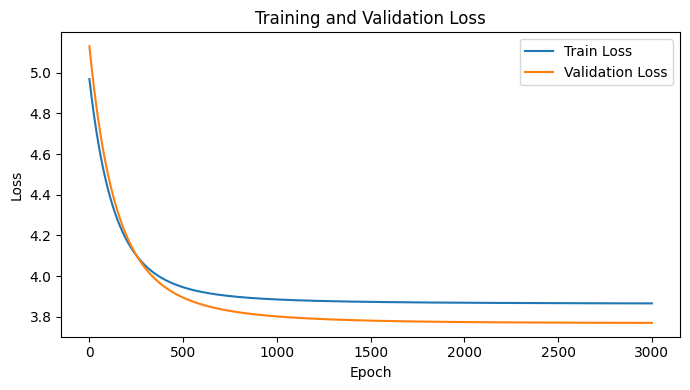

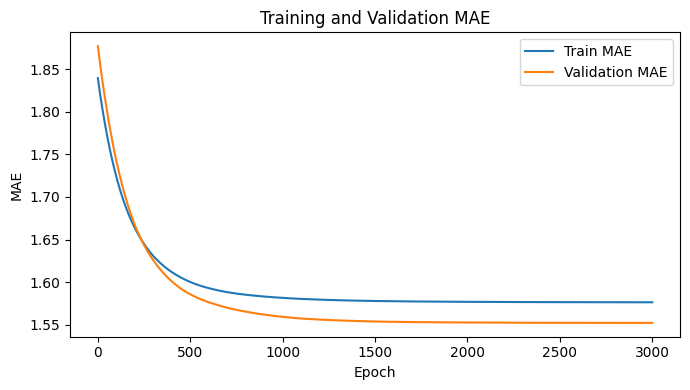

In [13]:
# Use the trained model and training scaler as the final model objects
scaler = scaler_train
clf = best_model

# Transform test set using the training scaler
Xte_s = scaler.transform(X_test)

# Plot training and validation loss history
plt.figure(figsize=(7, 4))
plt.plot(range(1, clf.epochs + 1), clf.loss_history_, label='Train Loss')

if len(clf.val_loss_history_) > 0:
    plt.plot(range(1, clf.epochs + 1), clf.val_loss_history_, label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot training and validation MAE history
plt.figure(figsize=(7, 4))
plt.plot(range(1, clf.epochs + 1), clf.train_mae_history_, label='Train MAE')

if len(clf.val_mae_history_) > 0:
    plt.plot(range(1, clf.epochs + 1), clf.val_mae_history_, label='Validation MAE')

plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

Test regression performance:
MAE : 1.538
RMSE: 1.914
R²  : 0.257


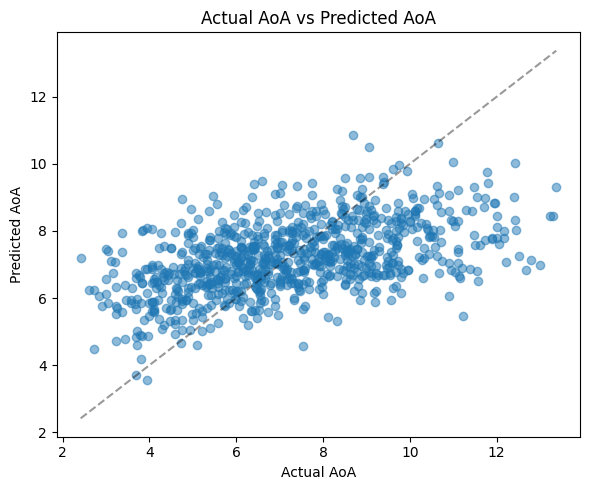

In [14]:
# Predict continuous AoA values for the test set
test_preds = clf.predict(Xte_s)

# Clip predicted AoA values into a realistic range
test_preds = np.clip(
    test_preds,
    PARAMETERS['min_pred_aoa'],
    PARAMETERS['max_pred_aoa']
)

# Calculate regression performance metrics on the test set
test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

# Print final test performance
print('Test regression performance:')
print(f'MAE : {test_mae:.3f}')
print(f'RMSE: {test_rmse:.3f}')
print(f'R²  : {test_r2:.3f}')


# Visualize how close predicted AoA values are to actual AoA values
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_preds, alpha=0.5)

# Reference line: perfect prediction would fall on this diagonal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    alpha=0.4
)

plt.title('Actual AoA vs Predicted AoA')
plt.xlabel('Actual AoA')
plt.ylabel('Predicted AoA')
plt.tight_layout()
plt.show()

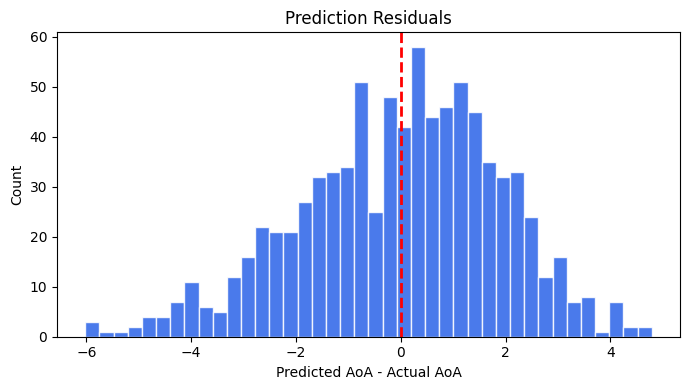

In [15]:
# Calculate residuals to inspect prediction errors
residuals = test_preds - y_test

# Plot residual distribution
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color='#2A63E8', alpha=0.85, edgecolor='white')

# Reference line at zero error
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.title('Prediction Residuals')
plt.xlabel('Predicted AoA - Actual AoA')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [16]:
# Example words for checking whether predictions are intuitively reasonable
test_words = [
    'the',
    'cat',
    'dog',
    'apple',
    'strength',
    'beautiful',
    'elephant',
    'metamorphosis',
    'word',
    'dyslexia',
    'meaningful'
]

print(f'\n{"Word":<20} {"Predicted AoA":<18} {"Category":<24} Message')
print('-' * 105)

# Predict AoA and support category for each example word
for word in test_words:
    predict_word(
        word,
        clf,
        scaler,
        PARAMETERS['target_age']
    )


Word                 Predicted AoA      Category                 Message
---------------------------------------------------------------------------------------------------------
the                  predicted_AoA=3.33   very_likely_familiar     Most children aged 7 would likely know this word
cat                  predicted_AoA=5.91   likely_familiar          Children aged 7 would likely know this word
dog                  predicted_AoA=5.63   likely_familiar          Children aged 7 would likely know this word
apple                predicted_AoA=6.25   likely_familiar          Children aged 7 would likely know this word
strength             predicted_AoA=6.55   around_target_age        This word may be around the expected level for children aged 7
beautiful            predicted_AoA=7.78   likely_unfamiliar        This word may be unfamiliar to children aged 7
elephant             predicted_AoA=8.34   likely_unfamiliar        This word may be unfamiliar to children aged 7
metamorphosis

In [17]:
# Check that the feature list, scaler, and trained model use the same feature size
assert len(FEATURES) == scaler.mean_.shape[0], (
    f'Feature mismatch: len(FEATURES)={len(FEATURES)}, '
    f'scaler={scaler.mean_.shape[0]}'
)

assert len(FEATURES) == clf.w_.shape[0], (
    f'Feature mismatch: len(FEATURES)={len(FEATURES)}, '
    f'model={clf.w_.shape[0]}'
)

# Save trained Ridge Regression model parameters for API deployment
model_artifact = {
    'model_type': 'ridge_regression',
    'w': clf.w_.tolist(),
    'b': float(clf.b_),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'target_age': float(PARAMETERS['target_age']),
    'min_pred_aoa': float(PARAMETERS['min_pred_aoa']),
    'max_pred_aoa': float(PARAMETERS['max_pred_aoa']),
    'features': FEATURES
}

# Write model artifact to JSON file
with open('word_difficulty_model.json', 'w') as f:
    json.dump(model_artifact, f)

print('Model saved.')

Model saved.


In [18]:
from google.colab import files

files.download('word_difficulty_model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>